In [1]:
import os

In [2]:

import warnings
warnings.filterwarnings('ignore')

# Get all the paths
data_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'

if not os.path.isdir(data_dir):
	raise FileNotFoundError(f'Directory does not exist: {data_dir}')

data_dir_list = os.listdir(data_dir)
print(data_dir_list)

path, dirs, files = next(os.walk(data_dir))
file_count = len(files)
print(file_count)

['Augmentation Details.txt', 'Benign cases', 'Malignant cases', 'Normal cases', 'Split_data_CNN_0', 'Split_data_inception_V3_1', 'Split_data_vgg16_o', 'train', 'validation']
1


In [3]:
# Make new base directory
original_dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
base_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_inception_V3_1'
os.makedirs(base_dir, exist_ok=True)

In [4]:
import os
#create two folders (train and validation)
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

In [ ]:
# Under the train folder, create one folder per class
train_benign_dir = os.path.join(train_dir, 'Benign cases')
os.makedirs(train_benign_dir, exist_ok=True)

train_malignant_dir = os.path.join(train_dir, 'Malignant cases')
os.makedirs(train_malignant_dir, exist_ok=True)

train_normal_dir = os.path.join(train_dir, 'Normal cases')
os.makedirs(train_normal_dir, exist_ok=True)

In [6]:
import os
import random
from shutil import copyfile

In [7]:
def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)

In [3]:
import os

# Use the dataset directory defined earlier or fall back to a valid dataset path
if 'original_dataset_dir' not in globals():
	original_dataset_dir = globals().get('data_dir', r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset')

data_dir = original_dataset_dir

if 'base_dir' not in globals():
	base_dir = os.path.join(data_dir, 'Split_data_inception_V3_1')

if 'train_dir' not in globals():
	train_dir = os.path.join(base_dir, 'train')

if 'validation_dir' not in globals():
	validation_dir = os.path.join(base_dir, 'validation')

# Ensure base directories exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(validation_dir, exist_ok=True)

# Create training and validation folders for each class
train_cloud_dir = os.path.join(train_dir, 'Benign cases')
train_foggy_dir = os.path.join(train_dir, 'Malignant cases')
train_normal_dir = os.path.join(train_dir, 'Normal cases')

validation_cloud_dir = os.path.join(validation_dir, 'Benign cases')
validation_foggy_dir = os.path.join(validation_dir, 'Malignant cases')
validation_normal_dir = os.path.join(validation_dir, 'Normal cases')

os.makedirs(train_cloud_dir, exist_ok=True)
os.makedirs(train_foggy_dir, exist_ok=True)
os.makedirs(train_normal_dir, exist_ok=True)

os.makedirs(validation_cloud_dir, exist_ok=True)
os.makedirs(validation_foggy_dir, exist_ok=True)
os.makedirs(validation_normal_dir, exist_ok=True)

# Source folders
BENGIN_SOURCE_DIR = os.path.join(data_dir, 'Benign cases')
MALIGNANT_SOURCE_DIR = os.path.join(data_dir, 'Malignant cases')
NORMAL_SOURCE_DIR = os.path.join(data_dir, 'Normal cases')

# Training and validation target folders
TRAINING_BENGIN_DIR = train_cloud_dir
VALID_BENGIN_DIR = validation_cloud_dir

TRAINING_MALIGNANT_DIR = train_foggy_dir
VALID_MALIGNANT_DIR = validation_foggy_dir

TRAINING_NORMAL_DIR = train_normal_dir
VALID_NORMAL_DIR = validation_normal_dir

NameError: name 'os' is not defined

In [ ]:
import os
import random
from shutil import copyfile
from pathlib import Path

def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        # Use os.path.join for robust path construction
        file_path = os.path.join(SOURCE, filename)
        if os.path.getsize(file_path) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TRAINING, filename)
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(VALIDATION, filename)
        copyfile(this_file, destination)

split_size = .80

# Locate the dataset folders under the current backend directory.
# This avoids using the missing ...\Dataset path.
excluded = Path(base_dir).resolve()

def find_dataset_folder(folder_name):
    matches = [
        p for p in Path(data_dir).rglob(folder_name)
        if p.is_dir() and p.resolve() != excluded
    ]

    if not matches:
        raise FileNotFoundError(
            f"'{folder_name}' was not found under:\n{data_dir}\n"
            "Set data_dir to the folder containing the dataset."
        )

    return str(matches[0])

BENGIN_SOURCE_DIR = find_dataset_folder('Benign cases')
MALIGNANT_SOURCE_DIR = find_dataset_folder('Malignant cases')
NORMAL_SOURCE_DIR = find_dataset_folder('Normal cases')

os.makedirs(TRAINING_BENGIN_DIR, exist_ok=True)
os.makedirs(VALID_BENGIN_DIR, exist_ok=True)
os.makedirs(TRAINING_MALIGNANT_DIR, exist_ok=True)
os.makedirs(VALID_MALIGNANT_DIR, exist_ok=True)
os.makedirs(TRAINING_NORMAL_DIR, exist_ok=True)
os.makedirs(VALID_NORMAL_DIR, exist_ok=True)

print("Benign source:", BENGIN_SOURCE_DIR)
print("Malignant source:", MALIGNANT_SOURCE_DIR)
print("Normal source:", NORMAL_SOURCE_DIR)

split_data(BENGIN_SOURCE_DIR, TRAINING_BENGIN_DIR, VALID_BENGIN_DIR, split_size)
split_data(MALIGNANT_SOURCE_DIR, TRAINING_MALIGNANT_DIR, VALID_MALIGNANT_DIR, split_size)
split_data(NORMAL_SOURCE_DIR, TRAINING_NORMAL_DIR, VALID_NORMAL_DIR, split_size)

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Benign cases', 'Malignant cases', 'Normal cases']
nimgs = {}
for i in image_folder:
    current_dir = os.path.join(train_dir, i)
    os.makedirs(current_dir, exist_ok=True)
    nimages = len(os.listdir(current_dir))
    nimgs[i] = nimages

plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

In [ ]:
import os
for i in ['Benign cases', 'Malignant cases', 'Normal cases']:
    print('Training {} images are: '.format(i)+str(len(os.listdir(os.path.join('C:\\Users\\Devar\\Desktop\\Lung Cancer Detection\\Dataset', i)))))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib
import os

image_folder = ['Benign cases', 'Malignant cases', 'Normal cases']
nimgs = {}
for i in image_folder:
    current_dir = os.path.join(validation_dir, i)
    os.makedirs(current_dir, exist_ok=True)
    nimages = len(os.listdir(current_dir))
    nimgs[i] = nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Testing Dataset')
plt.show()

In [14]:
!pip install tensorflow==2.21.0


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout
from keras.layers import Flatten

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [17]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=8,
                                   zoom_range=0.15,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.10,
                                   horizontal_flip=True,
                                   brightness_range=[0.8,1.2],
                                   channel_shift_range=0.15,
                                   fill_mode="nearest")

In [18]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
x_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical'
)

x_test = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(x_train.class_indices)
print(x_test.class_indices)

In [20]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [ ]:
from keras.models import Sequential

model = Sequential()
model.add(Convolution2D(32, (3, 3), input_shape=(224, 224, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Dropout(0.25))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 classes: Benign, Malignant, Normal

model.summary()

In [22]:
import tensorflow as tf
base_model=tf.keras.applications.inception_v3.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(299,299,3),
    pooling=None,
    classes=1000,
    classifier_activation='softmax'
)
for layer in base_model.layers:
    layer.trainable=False

In [ ]:
import tensorflow as tf
x = tf.keras.layers.Flatten()(base_model.output)
x = tf.keras.layers.Dense(512, activation='relu')(x)

x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(3, activation='softmax')(x)  # 3 classes: Benign, Malignant, Normal
model = tf.keras.models.Model(base_model.input, x)

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

In [26]:
TRAIN_STEPS_PER_EPOCH = len(x_train)
VAL_STEPS_PER_EPOCH = len(x_test)

print(f"TRAIN_STEPS_PER_EPOCH:{TRAIN_STEPS_PER_EPOCH}")
print(f"VAL_STEPS_PER_EPOCH:{VAL_STEPS_PER_EPOCH}")

TRAIN_STEPS_PER_EPOCH:75
VAL_STEPS_PER_EPOCH:44


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
EARLY_STOP_PATIENCE =5

In [ ]:
if 'train_dir' not in globals():
    train_dir = os.path.join(data_dir, 'train')

if 'validation_dir' not in globals():
    validation_dir = os.path.join(data_dir, 'validation')

if 'train_datagen' not in globals():
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=8,
        zoom_range=0.15,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.10,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        channel_shift_range=0.15,
        fill_mode='nearest'
    )

if 'test_datagen' not in globals():
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0 / 255
    )

if 'x_train' not in globals() or 'x_test' not in globals():
    x_train = train_datagen.flow_from_directory(
        train_dir,
        target_size=(299, 299),
        batch_size=32,
        class_mode='categorical'
    )

    x_test = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(299, 299),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

NUM_CLASSES = len(x_train.class_indices)
print("Classes:", x_train.class_indices)

TRAIN_STEPS_PER_EPOCH = len(x_train)
VAL_STEPS_PER_EPOCH = len(x_test)

if 'model' not in globals():
    base_model = tf.keras.applications.InceptionV3(
        include_top=False,
        weights='imagenet',
        input_shape=(299, 299, 3),
        pooling='avg'
    )

    base_model.trainable = False

    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(
        base_model.output
    )
    model = tf.keras.models.Model(base_model.input, outputs)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cb_early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOP_PATIENCE
)
cb_checkpointer = tf.keras.callbacks.ModelCheckpoint(
    filepath='Inception1_v3.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='auto',
    save_weights_only=True
)
callbacks = [cb_checkpointer, cb_early_stopper]

history = model.fit(
    x_train,
    steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    epochs=20,
    validation_data=x_test,
    validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=callbacks
)

In [32]:
import os

model_dir = r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models"
os.makedirs(model_dir, exist_ok=True)

model.save(os.path.join(model_dir, "Inception_V3_2.hdf5"))

In [33]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [34]:
if 'history' in globals() and hasattr(history, 'history'):
	keys = list(history.history.keys())
	print(keys)
else:
	print("Training history is not available. Run the model training cell first.")

['accuracy', 'loss', 'val_accuracy', 'val_loss']


In [35]:
%pip install --upgrade --force-reinstall --no-cache-dir scipy scikit-learn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/36.7 MB 25.1 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/36.7 MB 38.2 MB/s eta 0:00:01
   -------------------------- ------------- 24.1/36.7 MB 39.2 MB/s eta 0:00:01
   ---------------------------------------- 36.7/36.7 MB 44.8 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------- 12.5/12.5 MB 60.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 63.6 MB/s  0:00:00

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   ---------------------------------------- 0/6 [threadpoolctl]
   ---------------------------------------- 0/6 [threadpoolctl]
   ---------------------------------------- 0/6 [threadpoolctl]
   -

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.28.0 requires numpy<2,>=1.19.3, but you have numpy 2.5.2 which is incompatible.
streamlit 1.28.0 requires pack

In [ ]:
import tensorflow as tf

if 'model' not in globals():
    model = tf.keras.models.load_model(
        r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models\Inception_V3_2.hdf5"
    )

if 'x_test' not in globals():
    validation_path = globals().get(
        'validation_dir',
        r"C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_inception_V3_1\validation"
    )

    x_test = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0 / 255
    ).flow_from_directory(
        validation_path,
        target_size=(299, 299),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

class_names = list(x_test.class_indices.keys())

y_pred_probs = model.predict(x_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = x_test.classes

matrix = confusion_matrix(y_true, y_pred)
print(matrix)
print(accuracy_score(y_true, y_pred))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

In [ ]:
y_pred_probs = model.predict(x_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = x_test.classes

print(classification_report(y_true, y_pred, target_names=class_names))

print(confusion_matrix(y_true, y_pred))

In [38]:
if 'history' in globals() and hasattr(history, 'history'):
    keys = list(history.history.keys())
else:
    keys = []
    print("Training history is not available. Run the model training cell first.")
print(keys)
print(keys)

['accuracy', 'loss', 'val_accuracy', 'val_loss']
['accuracy', 'loss', 'val_accuracy', 'val_loss']


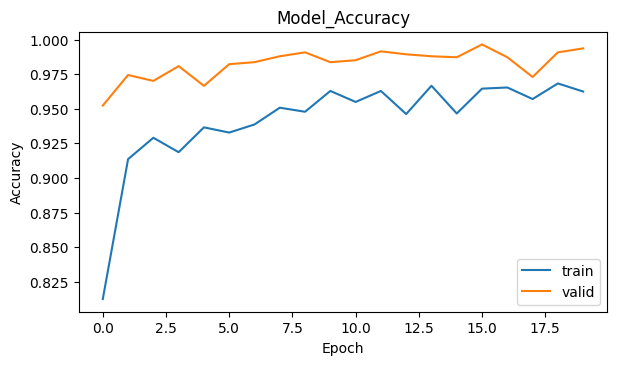

In [39]:
if 'history' in globals() and hasattr(history, 'history'):
	if 'accuracy' in history.history and 'val_accuracy' in history.history:
		plt.figure(1, figsize=(15, 8))
		plt.subplot(221)
		plt.plot(history.history['accuracy'])
		plt.plot(history.history['val_accuracy'])
		plt.title('Model_Accuracy')
		plt.ylabel('Accuracy')
		plt.xlabel('Epoch')
		plt.legend(['train', 'valid'])
		plt.show()
	else:
		print("Accuracy history is not available.")
else:
	print("Training history is not available. Run the model training cell first.")

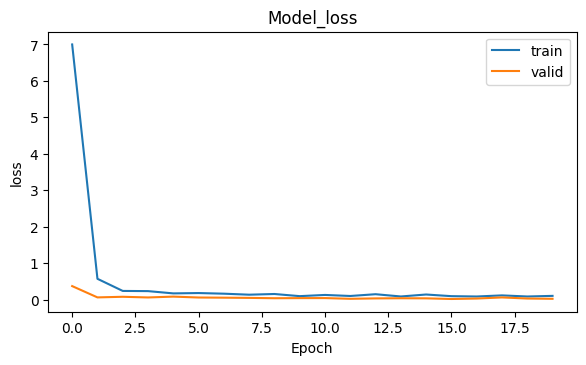

In [40]:
if 'history' in globals() and hasattr(history, 'history'):
	if 'loss' in history.history and 'val_loss' in history.history:
		plt.figure(1, figsize=(15, 8))
		plt.subplot(222)
		plt.plot(history.history['loss'])
		plt.plot(history.history['val_loss'])
		plt.title('Model_loss')
		plt.ylabel('loss')
		plt.xlabel('Epoch')
		plt.legend(['train', 'valid'])
		plt.show()
	else:
		print("Loss history is not available.")
else:
	print("Training history is not available. Run the model training cell first.")

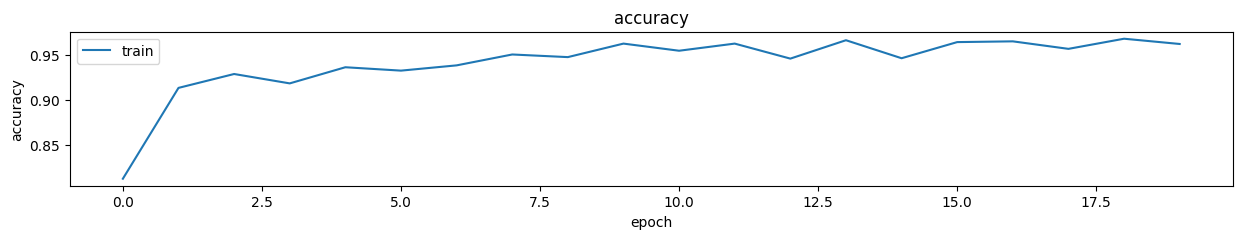

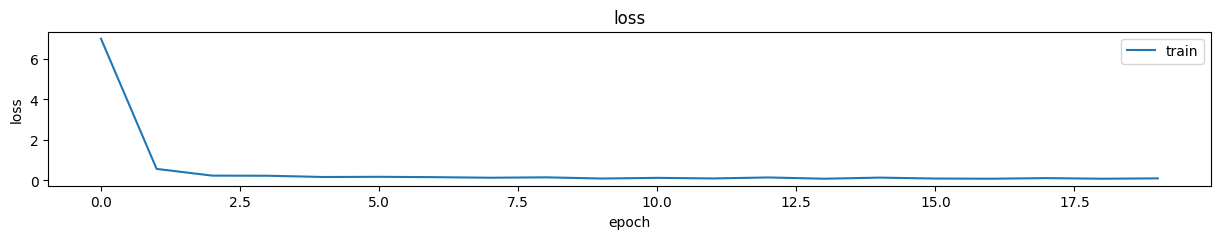

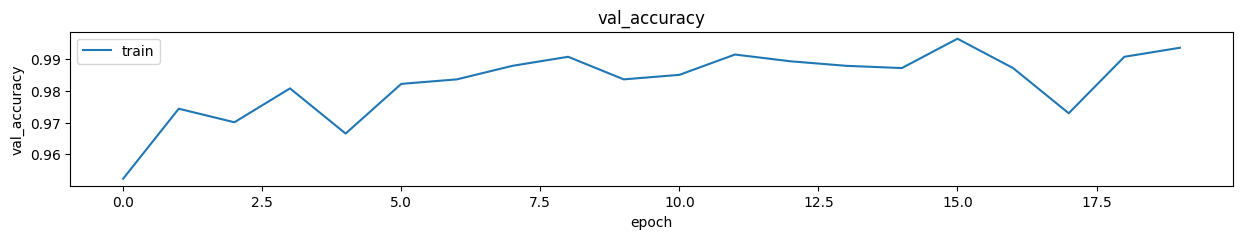

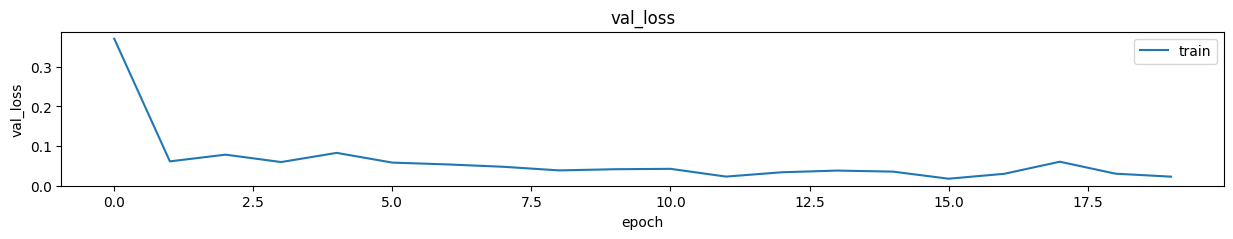

In [41]:
for key in keys:
  plt.figure(figsize=(15,2))
  plt.plot(history.history[key])
  plt.title(key)
  plt.ylabel(key)
  plt.xlabel('epoch')
  plt.legend(['train','valid'])

plt.show()

In [43]:
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import load_model
model = load_model(r'C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models\Inception_V3_2.hdf5')

In [44]:
%pip install opencv-python

from keras.preprocessing import image
import cv2
import numpy as np
import PIL
from PIL import Image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing import image

# Use the notebook variable that is already correct
validation_root = Path(validation_dir).resolve()
sample_dir = validation_root / "Malignant cases"   # try "Benign cases", "Malignant cases" or "Normal cases"

print("Looking in:", sample_dir)

if not sample_dir.exists():
    raise FileNotFoundError(f"Folder does not exist: {sample_dir}")

# Find any valid image in the folder instead of hard-coding one filename
img_files = sorted(sample_dir.glob("*.jpg")) + sorted(sample_dir.glob("*.png")) + sorted(sample_dir.glob("*.jpeg"))
if not img_files:
    raise FileNotFoundError(f"No image files found in: {sample_dir}")

img_path = str(img_files[0])
print("Loading image:", img_path)

img = image.load_img(img_path, target_size=(299, 299))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0   # same scaling used in training

class_names = ["Benign cases", "Malignant cases", "Normal cases"]

pred = model.predict(x, verbose=0)
pred_class = int(np.argmax(pred[0]))

print("Probabilities:", pred[0])
print("Prediction:", class_names[pred_class])
print("Confidence:", float(pred[0][pred_class]))

In [47]:
x=image.img_to_array(img)
x=np.expand_dims(x,axis=0)
x.shape

(1, 299, 299, 3)

In [48]:
pred = model.predict(x)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


array([[0.]], dtype=float32)

In [ ]:
class_names = ["Benign cases", "Malignant cases", "Normal cases"]
pred_class = int(np.argmax(pred[0]))
prediction = class_names[pred_class]
print(pred[0])
print(prediction)

In [50]:
!pip install pyngrok==4.1.1


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
!pip install flask_ngrok
!ngrok authtoken 2L2K2jLowvwGqsOFktpa14xk1Av_5n8dboKu9yH1PkyoiCgx2 #Without "" marks

from flask_ngrok import run_with_ngrok
from flask import Flask, render_template


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NAME:
   authtoken - save authtoken to configuration file

USAGE:
   ngrok authtoken [command options] [arguments...]

DESCRIPTION:
   The authtoken command modifies your configuration file to include
   the specified authtoken. By default, this configuration file is located
   at $HOME/.ngrok2/ngrok.yml

   The ngrok.com service requires that you sign up for an account to use
   many advanced service features. In order to associate your client with
   an account, it must pass a secret token to the ngrok.com service when it
   starts up. Instead of passing this authtoken on every invocation, you may
   use this command to save it into your configuration file so that your
   client always authenticates you properly.

EXAMPLE:
    ngrok authtoken BDZIXnhJt2HNWLXyQ5PM_qCaBq0W2sNFcCa0rfTZd

OPTIONS:
   --config 		save in this config file, default: ~/.ngrok2/ngrok.yml
   --log "false"	path to log file, 'stdout', 'stderr' or 'false'
   --log-format "term"	log record format: 'term', 'logfmt',

In [52]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [53]:
!pip install --upgrade gevent


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import os

os.makedirs('C:\\Users\\Devar\\Desktop\\Lung Cancer Detection\\Backend\\Webapp\\templates', exist_ok=True)
os.makedirs('C:\\Users\\Devar\\Desktop\\Lung Cancer Detection\\Backend\\Webapp\\static', exist_ok=True)

In [55]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from flask import Flask, request, render_template
from werkzeug.utils import secure_filename
from gevent.pywsgi import WSGIServer

In [56]:
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [57]:
from flask_ngrok import run_with_ngrok
from flask import Flask, redirect, url_for, request, render_template
from werkzeug.utils import secure_filename
from gevent.pywsgi import WSGIServer

In [58]:
MODEL_PATH = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models\Inception_V3_2.hdf5'
model = load_model(MODEL_PATH)
#print('Model Loaded. Check http://127.0.0.1:5000/')

In [ ]:
from flask import Flask, request, jsonify
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from tensorflow.keras.models import load_model

# Load the saved model
MODEL_PATH = os.path.join(
    r"C:\Users\Devar\Desktop\Lung Cancer Detection\Backend\Models",
    "Inception_V3_2.hdf5"
)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

model = load_model(MODEL_PATH)

# Class order must match the training generator's class_indices.
# Keras' flow_from_directory sorts class folders alphabetically, so this is:
# Benign cases -> 0, Malignant cases -> 1, Normal cases -> 2
CLASS_NAMES = ["Benign cases", "Malignant cases", "Normal cases"]

# Define a Flask app
app = Flask(__name__)

# Define a route for predicting the uploaded images
@app.route('/predict', methods=['POST'])
def predict():
    # Get the uploaded file from the request
    file = request.files['image']

    # Load the image and preprocess it the same way as training (rescale=1./255)
    img = image.load_img(file, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0

    # Make a prediction
    preds = model.predict(x)[0]
    class_index = int(np.argmax(preds))

    # Return the prediction result
    return jsonify({
        'class': CLASS_NAMES[class_index],
        'confidence': float(preds[class_index]),
        'probabilities': {
            CLASS_NAMES[i]: float(preds[i]) for i in range(len(CLASS_NAMES))
        }
    })

if __name__ == '__main__':
    app.run(debug=True)

In [ ]:
!pip install flask_ngrok
from flask import Flask
from flask_ngrok import run_with_ngrok

app = Flask(__name__ )
run_with_ngrok(app)

if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-58:
Traceback (most recent call last):
  File "C:\Users\Devar\AppData\Roaming\Python\Python312\site-packages\urllib3\connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Devar\AppData\Roaming\Python\Python312\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "C:\Users\Devar\AppData\Roaming\Python\Python312\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refuse